In [36]:
import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [37]:
SEED = 2912

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
torch.backends.cudnn.benchmark = True

In [38]:
DATASET_PATH = "../Dataset"
DATASET_NAME = "Mendeley_Dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-4
ACCUM_STEPS = 2
PATIENCE = 15
MIN_DELTA = 0.001

OUTPUT_DIR = f"../Results/{DATASET_NAME}/Model_4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [39]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 0.8)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [40]:
full_dataset = datasets.ImageFolder(f"{DATASET_PATH}/{DATASET_NAME}")

class_names = full_dataset.classes
num_classes = len(class_names)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(class_names)
print(num_classes)

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
7


In [41]:
import torch
import torch.nn as nn

class CrossAttentionCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Feature extractor
        self.conv1 = self._block(3, 16)
        self.conv2 = self._block(16, 32)
        self.conv3 = self._block(32, 64)
        self.conv4 = self._block(64, 128)

        # Project Conv2 to Conv4 dimension
        self.proj_c2 = nn.Conv2d(32, 128, kernel_size=1)

        # Cross Attention
        self.attn = nn.MultiheadAttention(
            embed_dim=128,
            num_heads=2,
            batch_first=True
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        # Lightweight classifier
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Linear(64, num_classes)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):

        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        f4 = self.conv4(f3)

        # Align Conv2 to Conv4
        f2_proj = self.proj_c2(f2)

        # Match spatial size
        f2_proj = nn.functional.interpolate(
            f2_proj,
            size=f4.shape[-2:]
        )

        # Flatten to tokens
        q = f4.flatten(2).transpose(1, 2)
        kv = f2_proj.flatten(2).transpose(1, 2)

        # Cross Attention
        attn_out, _ = self.attn(q, kv, kv)

        pooled = attn_out.transpose(1, 2)
        pooled = self.gap(pooled).squeeze(-1)

        x = self.fc(pooled)

        return self.classifier(x)

In [42]:
model = CrossAttentionCNN(num_classes).to(device)

In [43]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)

scaler = GradScaler()

In [44]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return total_loss/len(loader), acc, all_labels, all_preds

In [45]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_acc = 0
best_weights = copy.deepcopy(model.state_dict())
early_counter = 0

In [46]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    optimizer.zero_grad()

    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)

        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (i+1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item()*ACCUM_STEPS

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc + MIN_DELTA:
        best_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, f"{OUTPUT_DIR}/best_model.pth")
        early_counter = 0
    else:
        early_counter += 1

    if early_counter >= PATIENCE:
        print("Early stopping")
        break

Epoch 1/100
Train Acc: 0.1931 | Val Acc: 0.3393
Epoch 2/100
Train Acc: 0.2976 | Val Acc: 0.3977
Epoch 3/100
Train Acc: 0.3573 | Val Acc: 0.4464
Epoch 4/100
Train Acc: 0.3764 | Val Acc: 0.4821
Epoch 5/100
Train Acc: 0.4041 | Val Acc: 0.4659
Epoch 6/100
Train Acc: 0.4089 | Val Acc: 0.4789
Epoch 7/100
Train Acc: 0.4309 | Val Acc: 0.4854
Epoch 8/100
Train Acc: 0.4638 | Val Acc: 0.5032
Epoch 9/100
Train Acc: 0.4614 | Val Acc: 0.5065
Epoch 10/100
Train Acc: 0.4703 | Val Acc: 0.4497
Epoch 11/100
Train Acc: 0.4817 | Val Acc: 0.5114
Epoch 12/100
Train Acc: 0.4793 | Val Acc: 0.5390
Epoch 13/100
Train Acc: 0.4874 | Val Acc: 0.5211
Epoch 14/100
Train Acc: 0.5020 | Val Acc: 0.5455
Epoch 15/100
Train Acc: 0.5053 | Val Acc: 0.5308
Epoch 16/100
Train Acc: 0.5285 | Val Acc: 0.5438
Epoch 17/100
Train Acc: 0.5321 | Val Acc: 0.5698
Epoch 18/100
Train Acc: 0.5333 | Val Acc: 0.5260
Epoch 19/100
Train Acc: 0.5459 | Val Acc: 0.5877
Epoch 20/100
Train Acc: 0.5472 | Val Acc: 0.5860
Epoch 21/100
Train Acc: 0.560

In [47]:
model.load_state_dict(best_weights)

val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader)

In [48]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

results = {
    "accuracy": val_acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "mcc": mcc,
    "balanced_accuracy": bal_acc
}

print(results)
print(report)

{'accuracy': 0.6412337662337663, 'precision': 0.622487222823129, 'recall': 0.6412337662337663, 'f1': 0.6243022226884936, 'mcc': 0.5597321873397274, 'balanced_accuracy': 0.5676433612450952}
              precision    recall  f1-score   support

    Bacteria       0.81      0.90      0.85       126
       Fungi       0.56      0.65      0.60       139
     Healthy       0.27      0.07      0.11        42
    Nematode       0.60      0.55      0.57        11
        Pest       0.49      0.47      0.48       112
 Phytopthora       0.74      0.55      0.63        71
       Virus       0.68      0.78      0.73       115

    accuracy                           0.64       616
   macro avg       0.59      0.57      0.57       616
weighted avg       0.62      0.64      0.62       616



In [49]:
pd.DataFrame(history).to_csv(f"{OUTPUT_DIR}/history.csv", index=False)
pd.DataFrame([results]).to_csv(f"{OUTPUT_DIR}/summary.csv", index=False)

with open(f"{OUTPUT_DIR}/results.json","w") as f:
    json.dump(results,f,indent=4)

with open(f"{OUTPUT_DIR}/report.txt","w") as f:
    f.write(report)

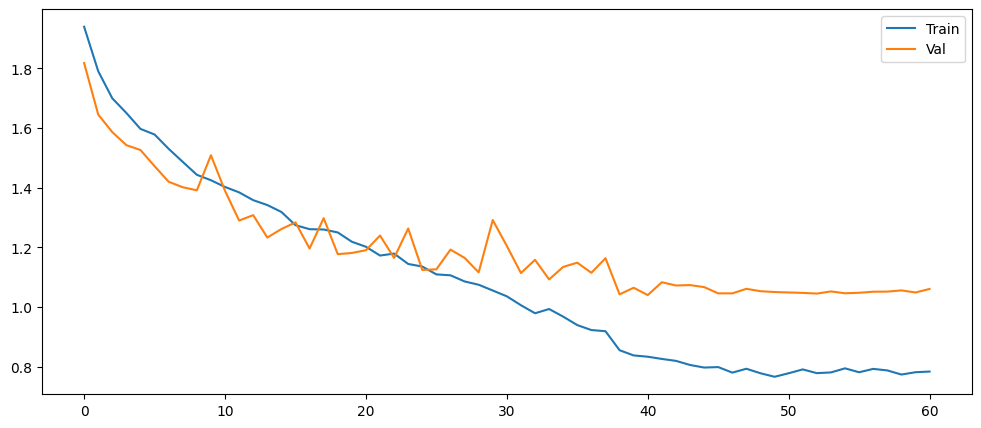

In [50]:
plt.figure(figsize=(12,5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png")
plt.show()

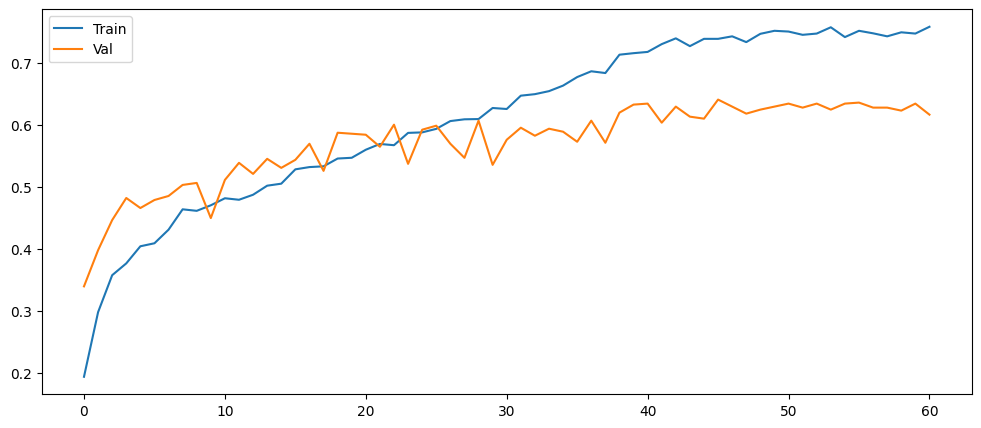

In [51]:
plt.figure(figsize=(12,5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/acc_curve.png")
plt.show()

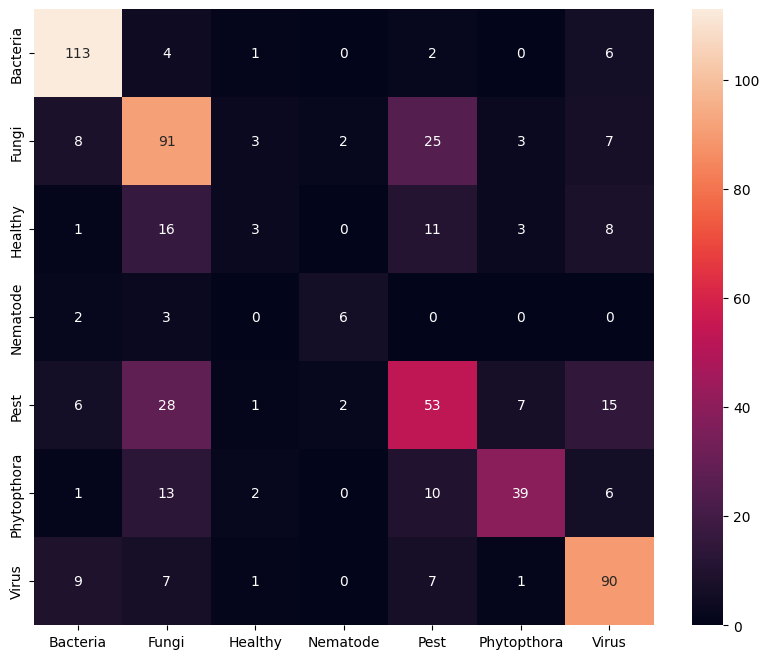

In [52]:
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
plt.show()